# Classification Track — Part A
## 00. Data Loading, EDA & Preprocessing

**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition (UCI / Kaggle)
**Team:** <Data Dynamos>
**Objective:** Predict `NObeyesdad` (7-class obesity level) from demographic, dietary and lifestyle attributes.

This notebook covers **Section A (Dataset & EDA)** and **Section B (Preprocessing & Feature Engineering)** of the Review 1 rubric.
Output of this notebook (processed train/test splits) is consumed by every algorithm notebook (`01`–`05`) so that
all five Part-A algorithms are trained and evaluated on the **exact same preprocessed data and the exact same test split**,
as required by the guidelines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder

RANDOM_STATE = 42
sns.set_style("whitegrid")
sns.set_palette("colorblind")
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)

### A1 — Dataset loading & audit

In [2]:
df = pd.read_csv("../data/ObesityDataSet_raw_and_data_sinthetic.csv")
print("Shape:", df.shape)
df.head()

Shape: (2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Data types:

Age                               float64
Gender                                str
Height                            float64
Weight                            float64
CALC                                  str
FAVC                                  str
FCVC                              float64
NCP                               float64
SCC                                   str
SMOKE                                 str
CH2O                              float64
family_history_with_overweight        str
FAF                               float64
TUE                               float64
CAEC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

Missing values per column:

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC          

In [4]:
print("Target class distribution:\n")
print(df['NObeyesdad'].value_counts())
print("\nAs percentage:\n")
print((df['NObeyesdad'].value_counts(normalize=True) * 100).round(2))

Target class distribution:

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

As percentage:

NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: proportion, dtype: float64


**Observation (A1):** The dataset has 2,111 rows and 17 columns (16 features + 1 target), with **no missing values and no
duplicate rows**. The target `NObeyesdad` has 7 classes that are reasonably balanced (roughly 260–350 samples each),
which is a favourable starting point for classification — we won't need aggressive class-imbalance correction, though
we will still use a stratified split to preserve this balance in both train and test sets.

### A2 — EDA Visualisations

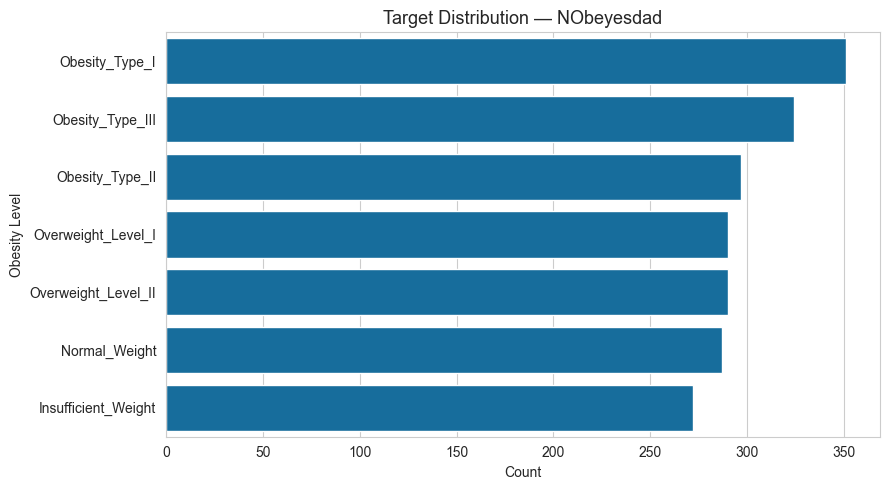

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df['NObeyesdad'].value_counts().index
sns.countplot(data=df, y='NObeyesdad', order=order, ax=ax)
ax.set_title("Target Distribution — NObeyesdad", fontsize=13)
ax.set_xlabel("Count")
ax.set_ylabel("Obesity Level")
plt.tight_layout()
plt.savefig("../results/fig_target_distribution.png", bbox_inches="tight")
plt.show()

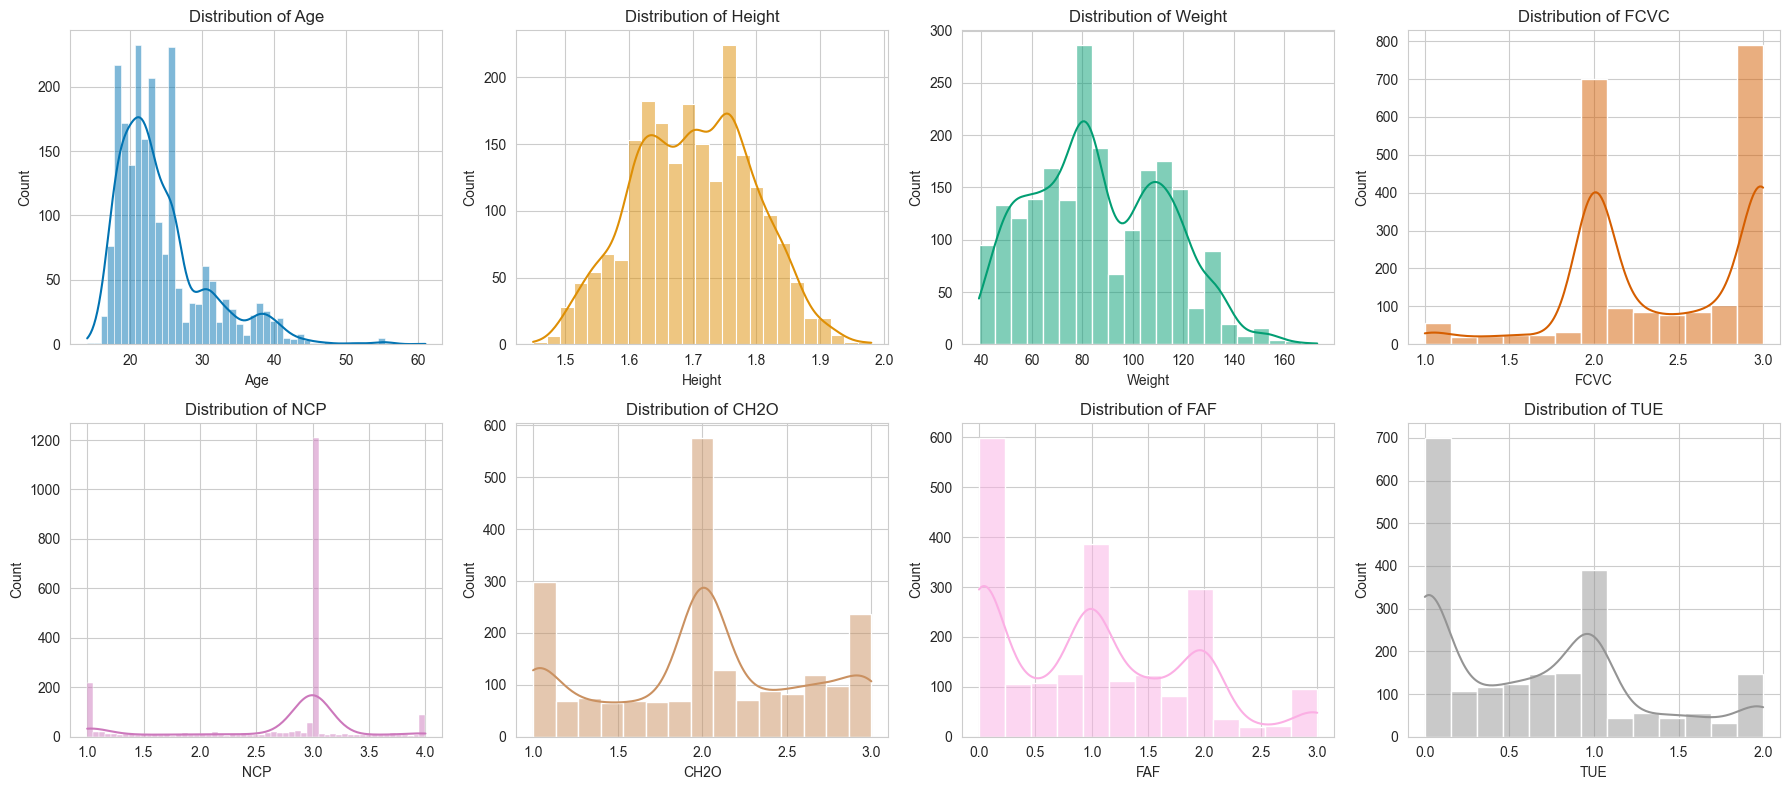

In [6]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("colorblind")[i % 8])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.savefig("../results/fig_feature_distributions.png", bbox_inches="tight")
plt.show()

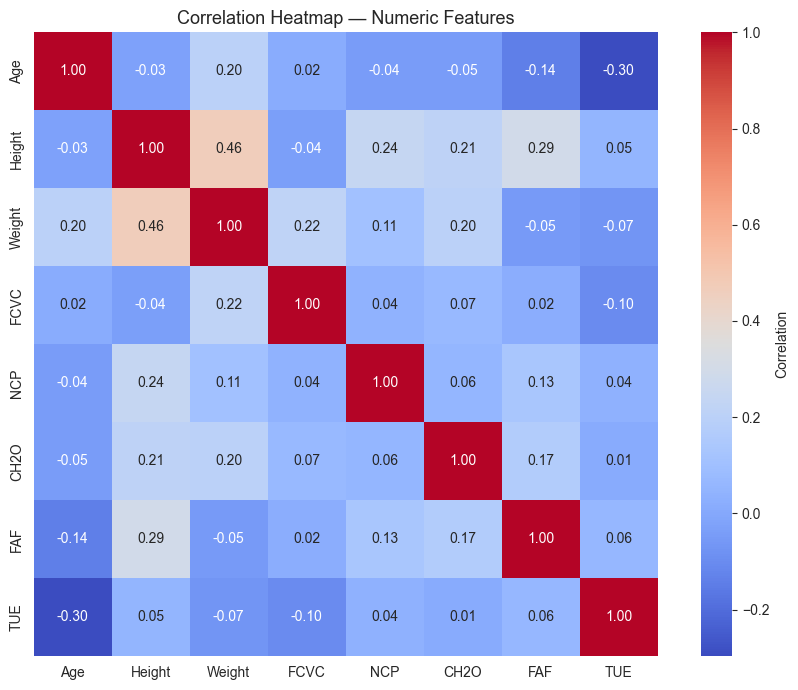

In [7]:
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap — Numeric Features", fontsize=13)
plt.tight_layout()
plt.savefig("../results/fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

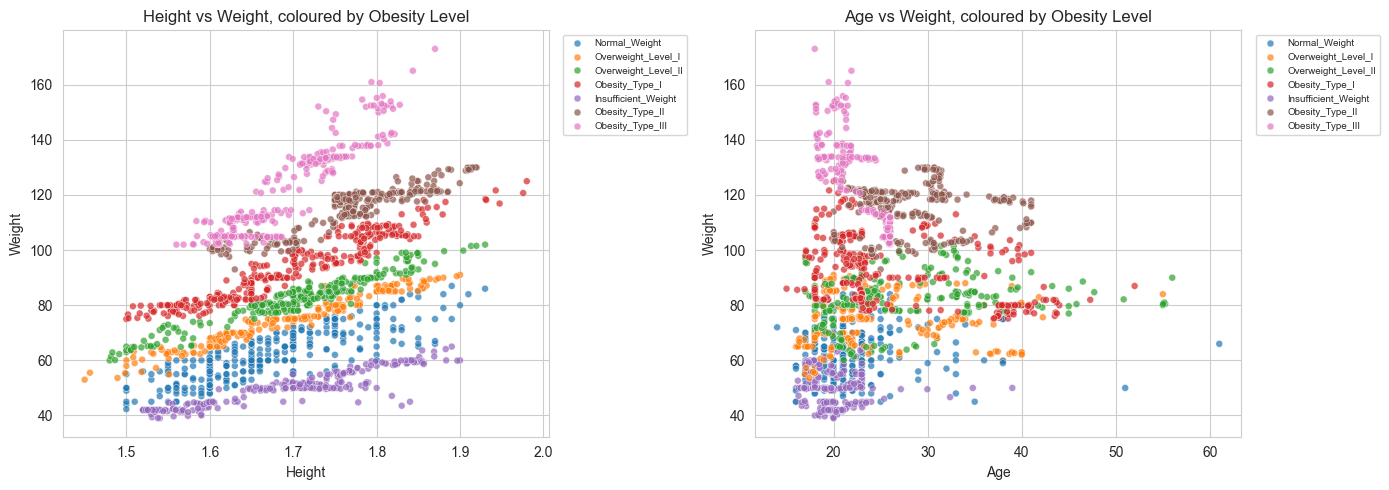

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad', palette='tab10', ax=axes[0], s=25, alpha=0.7)
axes[0].set_title("Height vs Weight, coloured by Obesity Level")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

sns.scatterplot(data=df, x='Age', y='Weight', hue='NObeyesdad', palette='tab10', ax=axes[1], s=25, alpha=0.7)
axes[1].set_title("Age vs Weight, coloured by Obesity Level")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig("../results/fig_scatter_feature_target.png", bbox_inches="tight")
plt.show()

**Observations (A3):**
- The correlation heatmap shows `Weight` and `Height` are the numeric features most related to obesity level, while
  lifestyle variables (`FAF`, `TUE`, `CH2O`) show weaker linear correlation — expected, since obesity level is driven
  more by the *combination* of weight-for-height than by any single lifestyle factor alone.
- The Height-vs-Weight scatter plot visibly separates into diagonal bands by obesity class — this is essentially the
  BMI relationship appearing directly in the raw features, which motivates the engineered `BMI` feature below.
- The Age-vs-Weight scatter shows most respondents are clustered between ages 18–30 (consistent with a survey-based
  dataset of a specific demographic), with weight spread widening for the higher obesity classes regardless of age.

### B1 — Data Cleaning

IQR-based outlier counts per numeric column:
  Age: 168
  Height: 1
  Weight: 1
  FCVC: 0
  NCP: 579
  CH2O: 0
  FAF: 0
  TUE: 0


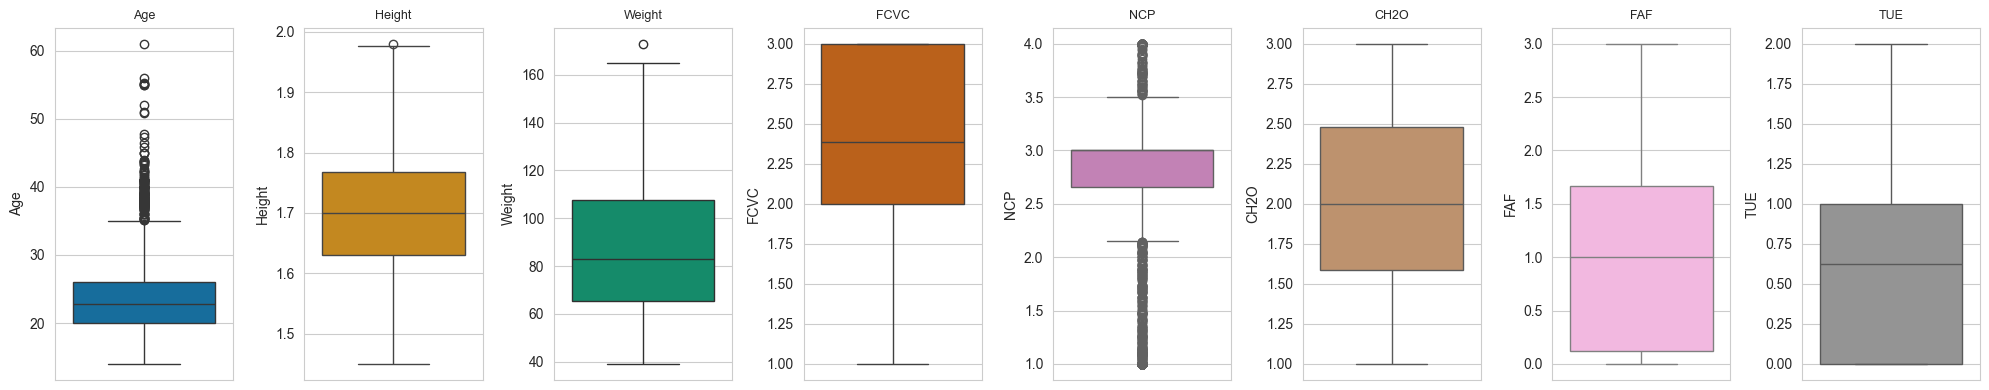

In [9]:
outlier_summary = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

print("IQR-based outlier counts per numeric column:")
for k, v in outlier_summary.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("colorblind")[i % 8])
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.savefig("../results/fig_boxplots.png", bbox_inches="tight")
plt.show()

**Cleaning strategy (B1):**
- **Missing values:** none found (verified above) — no imputation required.
- **Duplicates:** none found (verified above) — no rows dropped.
- **Outliers:** a small number of IQR-flagged points exist in `Age` and `Weight` (visible above). These are retained
  rather than removed, since they represent physiologically plausible values (e.g. older respondents, higher weights
  associated with severe obesity classes) rather than data-entry errors — removing them would bias the model against
  correctly recognising the more extreme obesity categories, which is exactly what we need it to detect.

### B3 — Feature Engineering

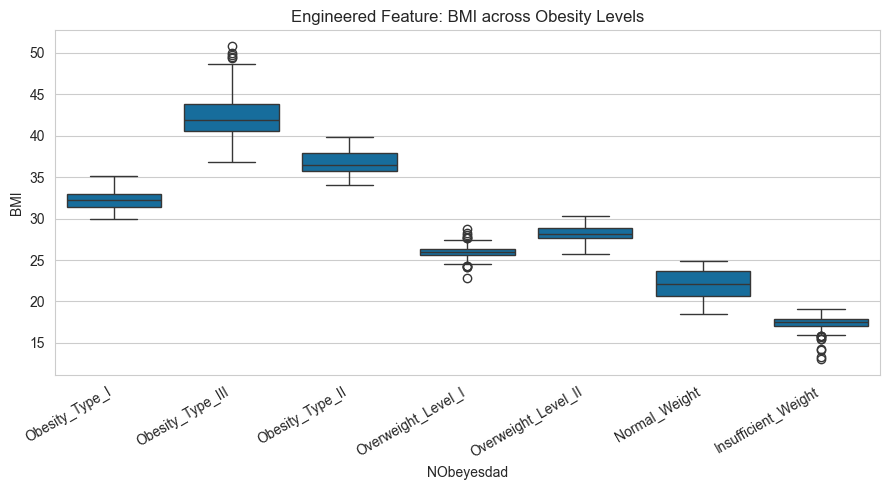

In [10]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='NObeyesdad', y='BMI', order=order, ax=ax)
ax.set_title("Engineered Feature: BMI across Obesity Levels")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("../results/fig_bmi_by_class.png", bbox_inches="tight")
plt.show()

**Justification (B3):** `BMI = Weight / Height^2` is a standard clinical index that directly encodes the
weight-for-height relationship visible in the earlier scatter plot as a single number instead of two separate
columns. As the boxplot shows, BMI increases in a clean, monotonic staircase across the seven ordered obesity
classes — making it likely to be one of the single most predictive features for tree-based models in particular,
and a useful additional signal for the linear/distance-based models even though `Weight` and `Height` are still
kept as individual features.

### B2 — Encoding, Scaling & Splitting

In [11]:
# Ordinal categorical features (natural order: no < Sometimes < Frequently < Always)
ordinal_cols = ['CAEC', 'CALC']
ordinal_order = [['no', 'Sometimes', 'Frequently', 'Always']] * 2
oe = OrdinalEncoder(categories=ordinal_order, handle_unknown='use_encoded_value', unknown_value=-1)
df[ordinal_cols] = oe.fit_transform(df[ordinal_cols])

# Binary categorical features -> map to 0/1
binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
for c in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    df[c] = df[c].map({'yes': 1, 'no': 0})

# Nominal categorical feature (no natural order) -> one-hot encode
df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS', dtype=int)

print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'NObeyesdad', 'BMI', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


In [12]:
le = LabelEncoder()
df['NObeyesdad_encoded'] = le.fit_transform(df['NObeyesdad'])
class_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print("Target class mapping:")
for k, v in sorted(class_mapping.items()):
    print(f"  {k} -> {v}")

pd.Series(class_mapping).to_csv("../data/processed/class_mapping.csv", header=["class_name"])

Target class mapping:
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Obesity_Type_I
  3 -> Obesity_Type_II
  4 -> Obesity_Type_III
  5 -> Overweight_Level_I
  6 -> Overweight_Level_II


In [13]:
X = df.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y = df['NObeyesdad_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3).sort_index())
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3).sort_index())

Train shape: (1688, 21)  Test shape: (423, 21)

Train class balance:
 NObeyesdad_encoded
0    0.129
1    0.136
2    0.166
3    0.140
4    0.153
5    0.137
6    0.137
Name: proportion, dtype: float64

Test class balance:
 NObeyesdad_encoded
0    0.128
1    0.137
2    0.165
3    0.142
4    0.154
5    0.137
6    0.137
Name: proportion, dtype: float64


In [14]:
scale_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])   # fit on TRAIN only
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])          # transform only on TEST

X_train_scaled.to_csv("../data/processed/X_train.csv", index=False)
X_test_scaled.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Saved processed train/test splits to data/processed/")
X_train_scaled.head()

Saved processed train/test splits to data/processed/


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,BMI,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
459,-0.830923,1,0.620541,-0.289869,2.0,1,-0.809585,0.402353,0,0,1.601927,1,-0.024257,2.242022,2.0,-0.523248,0,0,0,1,0
426,-0.361495,1,0.513995,-0.635417,0.0,0,-0.809585,0.402353,0,0,1.601927,0,-0.024257,0.576454,1.0,-0.853763,0,0,0,1,0
326,-0.987399,1,-0.018735,-1.199811,1.0,1,1.080202,0.402353,0,0,-0.029305,1,2.336114,-1.089115,1.0,-1.318625,0,0,0,1,0
971,-0.751685,1,1.307219,0.042472,1.0,1,0.690076,1.419764,0,0,0.670590,1,1.267506,-0.433950,1.0,-0.419530,0,0,0,1,0
892,-1.130536,0,-1.770158,-1.124592,1.0,1,-0.861469,-0.449641,1,0,-0.500610,0,-1.091715,0.894666,1.0,-0.675857,0,0,0,1,0


**Encoding/scaling summary (B2):**
- **Ordinal encoding** used for `CAEC` and `CALC` (frequency-of-consumption columns) since they have a genuine
  natural order (no < Sometimes < Frequently < Always).
- **Binary mapping** used for `Gender` and the four yes/no lifestyle columns.
- **One-hot encoding** used for `MTRANS` (mode of transport) since its categories have no natural order.
- **StandardScaler** fitted **only on the training set** and then applied to both train and test sets, to avoid
  data leakage, as required by the guidelines.
- **Stratified 80:20 split** used (`stratify=y`) so that the near-balanced class proportions are preserved in
  both the training and test sets — important since we'll be comparing 10 algorithms fairly on the same split.

All five Part-A algorithm notebooks load `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` from this point
onward, guaranteeing every algorithm is trained and evaluated on identical data.